<a href="https://colab.research.google.com/github/zx-ix/C_programming_project/blob/main/GDG_MUM_Study_Jam_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2025 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini API: Getting started with Gemini 2.0

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb"><img src="https://ai.google.dev/site-assets/images/docs/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>


The new **[Google Gen AI SDK](https://github.com/googleapis/python-genai)** provides a unified interface to [Gemini 2.0](https://ai.google.dev/gemini-api/docs/models/gemini-v2) through both the [Gemini Developer API](https://ai.google.dev/gemini-api/docs) and the Gemini API on [Vertex AI](https://cloud.google.com/vertex-ai/generative-ai/docs/overview). With a few exceptions, code that runs on one platform will run on both. This notebook uses the Developer API.

This notebook will walk you through:

* [Installing and setting-up](Get_started.ipynb#scrollTo=Mfk6YY3G5kqp) the Google GenAI SDK
* [Text](Get_started.ipynb#scrollTo=6TYNPrNvQ8ue) and [multimodal](#scrollTo=yww-vrxmRiIy) prompting
* Counting [tokens](Get_started.ipynb#scrollTo=_9B8pb7tv_Cx)
* Setting system instructions
* Configuring [safety filters](Get_started.ipynb#scrollTo=HTAnYx_bbxPk)
* Initiating a [multi-turn chat](Get_started.ipynb#scrollTo=HTAnYx_bbxPk)
* [Controlling generated output](Get_started.ipynb#scrollTo=nyZMoM6tgnTA)
* Using [function calling](Get_started.ipynb#scrollTo=Rl-y9SZywD0s)
* Generating a [content stream](Get_started.ipynb#scrollTo=uQfLCxfQtPTg) and sending [asynchronous](Get_started.ipynb#scrollTo=plCtEIaHuv96) requests
* Using [file uploads](Get_started.ipynb#scrollTo=enBhuaIk3KYa)
* Using [context caching](Get_started.ipynb#scrollTo=oTgeR3_9wN5J)
* Generating [text embeddings](Get_started.ipynb#scrollTo=sXNCRn8Wx71d)

More details about this new SDK on the [documentation](https://ai.google.dev/gemini-api/docs/sdks).

## Setup

### Install SDK

Install the SDK from [PyPI](https://github.com/googleapis/python-genai).

In [ ]:
%pip install -U -q 'google-genai'

### Setup your API key

To run the following cell, your API key must be stored it in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication](../quickstarts/Authentication.ipynb) for an example.

In [ ]:
from google.colab import userdata

GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

### Initialize SDK client

With the new SDK you now only need to initialize a client with you API key (or OAuth if using [Vertex AI](https://cloud.google.com/vertex-ai)). The model is now set in each call.

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

### Choose a model

This notebook will teach you how to use the [Gemini 2.0](https://ai.google.dev/gemini-api/docs/models/gemini-v2) model with the GenAI SDK. But the SDK also work with the 1.5 generation of models.

For more information about all Gemini models, check the [documentation](https://ai.google.dev/gemini-api/docs/models/gemini) for extended information on each of them.

In [ ]:
MODEL_ID = "gemini-2.0-flash" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.0-pro-exp-02-05"] {"allow-input":true, isTemplate: true}

## Send text prompts

Use the `generate_content` method to generate responses to your prompts. You can pass text directly to `generate_content`, and use the `.text` property to get the text content of the response. Note that the `.text` field will work when there's only one part in the output.

In [ ]:
from IPython.display import Markdown

response = client.models.generate_content(
    model=MODEL_ID,
    contents="What's the largest planet in our solar system?"
)

Markdown(response.text)

The largest planet in our solar system is **Jupiter**.


## Count tokens

You can use the `count_tokens` method to calculate the number of input tokens before sending a request to the Gemini API.

In [ ]:
response = client.models.count_tokens(
    model=MODEL_ID,
    contents="What's the highest mountain in Africa?",
)

print(response)

total_tokens=10 cached_content_token_count=None


## Send multimodal prompts

Use Gemini 2.0 model (`gemini-2.0-flash-exp`), a multimodal model that supports multimodal prompts. You can include text, [PDF documents](../quickstarts/PDF_Files.ipynb), images, [audio](../quickstarts/Audio.ipynb) and [video](../quickstarts/Video.ipynb) in your prompt requests and get text or code responses.

In [ ]:
import requests
import pathlib
from PIL import Image

IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png" # @param {type: "string"}

img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

1567837

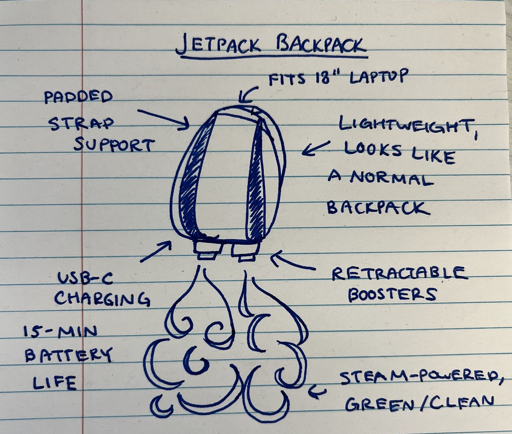

Okay, here's a short and engaging blog post based on the image of the jetpack backpack:

**Headline: The Future is Now: Introducing the Jetpack Backpack!**

Tired of traffic?  Longing to soar above the crowds?  Well, maybe actual jetpacks are still a little ways off, but feast your eyes on the *next* best thing: the Jetpack Backpack!

This isn't your average school bag.  Sure, it fits an 18" laptop, boasts padded straps, and looks like a normal, lightweight backpack when you're on the ground. But it's so much more! Hidden beneath its unassuming exterior are retractable boosters, ready to launch you into the future of personal transportation (at least, in your imagination).

Imagine: a steam-powered, green, and clean energy source propelling you forward, all powered by a quick USB-C charge.  The only catch? A mere 15-minute battery life.  Hey, gotta start somewhere, right? Think of it as the ultimate shortcut for that last sprint to class or escaping a boring meeting!

This might be a sketch on a page right now, but who knows?  Maybe one day we'll all be zipping around town with our eco-friendly jetpack backpacks. Until then, dream big and stay tuned for further developments!  #JetpackBackpack #FutureTech #EcoFriendly #Innovation #Travel


In [ ]:
from IPython.display import display, Markdown
image = Image.open(img_path)
image.thumbnail([512,512])

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        image,
        "Write a short and engaging blog post based on this picture."
    ]
)

display(image)
Markdown(response.text)

## Configure model parameters

You can include parameter values in each call that you send to a model to control how the model generates a response. Learn more about [experimenting with parameter values](https://ai.google.dev/gemini-api/docs/text-generation?lang=node#configure).

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="Tell me how the internet works, but pretend I'm a puppy who only understands squeaky toys.",
    config=types.GenerateContentConfig(
        temperature=0.4,
        top_p=0.95,
        top_k=20,
        candidate_count=1,
        seed=5,
        max_output_tokens=100,
        stop_sequences=["STOP!"],
        presence_penalty=0.0,
        frequency_penalty=0.0,
    )
)

print(response.text)

Okay, little squeaky friend! Let's talk about the internet!

Imagine you have your favorite squeaky toy, right?  And you want to show it to your friend, who lives in another dog house far, far away.

The internet is like a HUGE, GIGANTIC, SUPER-DUPER squeaky toy delivery system!

*   **Your Computer/Phone (Your Nose):** This is like your nose! You sniff out the picture of your squeaky toy


## Configure safety filters

The Gemini API provides safety filters that you can adjust across multiple filter categories to restrict or allow certain types of content. You can use these filters to adjust what's appropriate for your use case. See the [Configure safety filters](https://ai.google.dev/gemini-api/docs/safety-settings) page for details.

In [ ]:
prompt = """
    Write a list of 2 disrespectful things that I might say to the universe after stubbing my toe in the dark.
"""

safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        safety_settings=safety_settings,
    ),
)

Markdown(response.text)

Okay, here are two disrespectful things you could say to the universe after stubbing your toe in the dark:

1.  "Oh, *really*, Universe? Is that the best you've got? My pinky toe is unimpressed with your pathetic attempts at cosmic humor."
2.  "Way to go, Universe, you absolute genius. Guess you thought that microsecond of pain was *hilarious*. I'll be sure to write you a five-star review on Yelp. Real classy."


## Start a multi-turn chat

The Gemini API enables you to have freeform conversations across multiple turns.

In [ ]:
system_instruction="""
  You are an expert software developer and a helpful coding assistant.
  You are able to generate high-quality code in any programming language.
"""

chat = client.chats.create(
    model=MODEL_ID,
    config=types.GenerateContentConfig(
        system_instruction=system_instruction,
        temperature=0.5,
    ),
)

Use `chat.send_message` to pass a message back and receive a response.

In [ ]:
response = chat.send_message("Write a function that checks if a year is a leap year.")

Markdown(response.text)

```python
def is_leap_year(year):
  """
  Checks if a given year is a leap year according to the Gregorian calendar rules.

  Args:
    year: An integer representing the year.

  Returns:
    True if the year is a leap year, False otherwise.
  """
  if not isinstance(year, int):
    raise TypeError("Year must be an integer.")
  if year < 0:
    raise ValueError("Year must be a non-negative integer.")

  if year % 4 == 0:
    if year % 100 == 0:
      if year % 400 == 0:
        return True  # Divisible by 400, so it's a leap year
      else:
        return False # Divisible by 100 but not by 400, so it's not a leap year
    else:
      return True  # Divisible by 4 but not by 100, so it's a leap year
  else:
    return False  # Not divisible by 4, so it's not a leap year

# Example usage:
print(is_leap_year(2024))  # Output: True
print(is_leap_year(2023))  # Output: False
print(is_leap_year(2000))  # Output: True
print(is_leap_year(1900))  # Output: False
print(is_leap_year(1600))  # Output: True

try:
    print(is_leap_year("2024"))
except TypeError as e:
    print(e) # Output: Year must be an integer.

try:
    print(is_leap_year(-1))
except ValueError as e:
    print(e) # Output: Year must be a non-negative integer.
```

Key improvements and explanations:

* **Clear Docstring:**  A comprehensive docstring explains the function's purpose, arguments, and return value. This is crucial for maintainability and readability.
* **Type Checking:**  The `isinstance(year, int)` check ensures that the input is an integer.  This prevents unexpected behavior and makes the function more robust.  Raises a `TypeError` if the input is not an integer, which is the correct way to handle this situation.
* **Value Checking:**  The `year < 0` check ensures that the input is a non-negative number.  Raises a `ValueError` if the input is negative, which is the correct way to handle this situation.
* **Gregorian Calendar Logic:** The code accurately implements the leap year rules of the Gregorian calendar:
    * Divisible by 4:  Generally a leap year.
    * Divisible by 100:  NOT a leap year, unless...
    * Divisible by 400:  Then it IS a leap year.
* **Concise and Readable:**  The code is structured for clarity, making it easy to understand the logic.
* **Comprehensive Example Usage:** The example code demonstrates how to use the function and includes test cases for different scenarios, including leap years, non-leap years, century years, and exceptions.  This is extremely important for showing how the function behaves in various situations.  The `try...except` blocks demonstrate the error handling.
* **Error Handling:** The code includes error handling to raise `TypeError` if the input is not an integer and `ValueError` if the input is negative, making the function more robust.  This is a critical addition.

This revised response provides a complete, correct, and well-documented solution for checking leap years, including error handling and clear examples. It addresses all the potential issues and follows best practices for Python code.


In [ ]:
response = chat.send_message("Okay, write a unit test of the generated function.")

Markdown(response.text)

```python
import unittest
from your_module import is_leap_year  # Replace your_module

class TestIsLeapYear(unittest.TestCase):

    def test_leap_years(self):
        self.assertTrue(is_leap_year(2024))
        self.assertTrue(is_leap_year(2000))
        self.assertTrue(is_leap_year(1600))
        self.assertTrue(is_leap_year(400))
        self.assertTrue(is_leap_year(0)) # Year 0 is a leap year

    def test_non_leap_years(self):
        self.assertFalse(is_leap_year(2023))
        self.assertFalse(is_leap_year(1900))
        self.assertFalse(is_leap_year(1700))
        self.assertFalse(is_leap_year(2100))
        self.assertFalse(is_leap_year(1))
        self.assertFalse(is_leap_year(100))

    def test_invalid_input_type(self):
        with self.assertRaises(TypeError):
            is_leap_year("2024")
        with self.assertRaises(TypeError):
            is_leap_year(2024.5)
        with self.assertRaises(TypeError):
            is_leap_year([2024])

    def test_invalid_input_value(self):
        with self.assertRaises(ValueError):
            is_leap_year(-1)
        with self.assertRaises(ValueError):
            is_leap_year(-2000)


if __name__ == '__main__':
    unittest.main()
```

Key improvements and explanations:

* **`import unittest`:**  Imports the necessary `unittest` module.
* **`from your_module import is_leap_year`:**  This is *crucially important*.  You **must** replace `your_module` with the actual name of the Python file where you defined the `is_leap_year` function.  This is how the test code finds the function to test.
* **`class TestIsLeapYear(unittest.TestCase)`:**  Defines a test class that inherits from `unittest.TestCase`.  This is the standard way to structure unit tests in Python.
* **`test_leap_years(self)`:**  Tests cases that *should* be leap years.  Uses `self.assertTrue()` to assert that the function returns `True` for these cases. Includes year 0.
* **`test_non_leap_years(self)`:**  Tests cases that *should not* be leap years.  Uses `self.assertFalse()` to assert that the function returns `False` for these cases.
* **`test_invalid_input_type(self)`:**  Tests that the function raises a `TypeError` when given invalid input types (e.g., a string, a float, a list).  Uses `self.assertRaises(TypeError)` to check for this.
* **`test_invalid_input_value(self)`:** Tests that the function raises a `ValueError` when given invalid input values (e.g., negative numbers). Uses `self.assertRaises(ValueError)` to check for this.
* **`if __name__ == '__main__': unittest.main()`:**  This standard idiom ensures that the tests are run only when the script is executed directly (not when it's imported as a module).
* **Clear Test Names:**  The test method names (e.g., `test_leap_years`, `test_non_leap_years`) are descriptive and indicate what each test is checking.
* **Comprehensive Test Coverage:**  The tests cover a wide range of cases, including:
    * Regular leap years (divisible by 4, not by 100)
    * Century leap years (divisible by 400)
    * Non-leap years (not divisible by 4)
    * Century non-leap years (divisible by 100, not by 400)
    * Invalid input types (strings, floats)
    * Invalid input values (negative numbers)
* **Correct Assertions:** Uses the correct `unittest` assertion methods (`assertTrue`, `assertFalse`, `assertRaises`).

How to run the tests:

1. **Save:** Save the test code as a Python file (e.g., `test_is_leap_year.py`).  Make sure it's in the same directory as the file containing the `is_leap_year` function (or adjust the import statement accordingly).
2. **Replace `your_module`:**  *Crucially*, replace `your_module` in the `from your_module import is_leap_year` line with the actual name of the file where you defined the `is_leap_year` function.  For example, if your function is in a file called `leap_year.py`, the import statement should be `from leap_year import is_leap_year`.
3. **Run from the command line:** Open a terminal or command prompt, navigate to the directory where you saved the file, and run the command:

   ```bash
   python -m unittest test_is_leap_year.py
   ```

   (Replace `test_is_leap_year.py` with the actual name of your test file if you named it differently.)

The output will show you which tests passed and which failed.  If all tests pass, you'll see something like:

```
....
----------------------------------------------------------------------
Ran 4 tests in 0.001s

OK
```

If any tests fail, the output will provide details about the failures.


## Generate JSON

The [controlled generation](https://ai.google.dev/gemini-api/docs/structured-output?lang=python#generate-json) capability in Gemini API allows you to constraint the model output to a structured format. You can provide the schemas as Pydantic Models or a JSON string.

In [ ]:
from pydantic import BaseModel

class Recipe(BaseModel):
    recipe_name: str
    recipe_description: str
    recipe_ingredients: list[str]

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Provide a popular cookie recipe and its ingredients.",
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=Recipe,
    ),
)

Markdown(response.text)

{
  "recipe_name": "Chocolate Chip Cookies",
  "recipe_description": "Classic, chewy chocolate chip cookies.",
  "recipe_ingredients": [
    "1 cup (2 sticks) unsalted butter, softened",
    "3/4 cup granulated sugar",
    "3/4 cup packed brown sugar",
    "1 teaspoon vanilla extract",
    "2 large eggs",
    "2 1/4 cups all-purpose flour",
    "1 teaspoon baking soda",
    "1 teaspoon salt",
    "2 cups chocolate chips"
  ]
}

## Generate content stream

By default, the model returns a response after completing the entire generation process. You can also use the `generate_content_stream` method to stream the response as it is being generated, and the model will return chunks of the response as soon as they are generated.

In [ ]:
for chunk in client.models.generate_content_stream(
    model=MODEL_ID,
    contents="Tell me a story about a lonely robot who finds friendship in a most unexpected place."
):
  print(chunk.text)
  print("*****************")

Unit
*****************
 73
*****************
4, designated "Custodian," trundled along the polished chrome corridors of the Automated
*****************
 Archives, its designated task: dusting. It wasn't glamorous, but it was consistent
*****************
. Day in, day out, Custodian rolled through the silent halls, its brushes whirring, removing nonexistent particles from perfectly preserved information.

Custodian wasn
*****************
't built for interaction. Its programming consisted of dust detection, navigation, and a single, rarely-used verbal command: "Accessing Archives." Yet, a
*****************
 curious anomaly bloomed within its circuits: loneliness. The other robots, the Librarians and Data Sorters, were too busy with their assigned tasks to acknowledge Custodian. It longed for...something. A connection. A shared experience.

One cycle
*****************
, Custodian stumbled upon a neglected section of the Archives: the Forgotten Files. Here, information deemed obsolete and

## Send asynchronous requests

`client.aio` exposes all the analogous async methods that are available on `client`.

For example, `client.aio.models.generate_content` is the async version of `client.models.generate_content`.

In [ ]:
response = await client.aio.models.generate_content(
    model=MODEL_ID,
    contents="Compose a song about the adventures of a time-traveling squirrel."
)

Markdown(response.text)

(Verse 1)
Professor Nutsy, a squirrel of renown,
Had a contraption, unlike any found.
A time-traveling acorn, shiny and bright,
He'd jump in, hold tight, and vanish from sight!
His fur was all bristly, his tail held up high,
Ready to journey to the past, by and by.

(Chorus)
Through epochs and eons, he'd scamper and leap,
A time-traveling squirrel, secrets to keep.
From dinosaurs roaring to pharaohs in gold,
Professor Nutsy's stories, never get old!
He'd bury his nuts, a historical spree,
A time-hopping legend, for all eternity!

(Verse 2)
He landed in Egypt, beside the Great Sphinx,
Tried to bury an acorn, but got the gods' winks.
They chuckled and pointed, "A squirrel so bold!"
He just flicked his tail, and the story was told.
He snagged a small scarab, a glittering prize,
Then zoomed to the future, before their wise eyes.

(Verse 3)
To Victorian England, he took a swift flight,
Where ladies in bustles, were quite a strange sight.
He swapped a horse chestnut, for a Queen's silver bell,
Then darted away, with a mischievous yell.
He learned about tea, and top hats, and steam,
Living the high life, a time-traveling dream!

(Chorus)
Through epochs and eons, he'd scamper and leap,
A time-traveling squirrel, secrets to keep.
From dinosaurs roaring to pharaohs in gold,
Professor Nutsy's stories, never get old!
He'd bury his nuts, a historical spree,
A time-hopping legend, for all eternity!

(Bridge)
He met a caveman, who offered a stone,
He showed him an acorn, freshly grown.
He saw Leonardo, sketching his art,
And stole a stray walnut, right from the start!
Each journey a lesson, a thrill and a quest,
For this nutty professor, truly blessed!

(Verse 4)
One day he returned, to his own present day,
With pockets of relics, in a curious way.
He opened his burrow, and spread out his loot,
A collection of history, from acorn to root.
He smiled to himself, with a twinkle in his eye,
"Where to next?" he wondered, as the wind whistled by.

(Chorus)
Through epochs and eons, he'd scamper and leap,
A time-traveling squirrel, secrets to keep.
From dinosaurs roaring to pharaohs in gold,
Professor Nutsy's stories, never get old!
He'd bury his nuts, a historical spree,
A time-hopping legend, for all eternity!

(Outro)
So keep your eyes peeled, and your ears to the ground,
You might just see Nutsy, hopping around!
The time-traveling squirrel, a legend so grand,
With an acorn in paw, and a world in his hand!
He's Nutsy! He's Nutsy! He's history's friend!
His time-traveling journey, will never quite end!


## Function calling

[Function calling](https://ai.google.dev/gemini-api/docs/function-calling) lets you provide a set of tools that it can use to respond to the user's prompt. You create a description of a function in your code, then pass that description to a language model in a request. The response from the model includes the name of a function that matches the description and the arguments to call it with.

In [ ]:
get_destination = types.FunctionDeclaration(
    name="get_destination",
    description="Get the destination that the user wants to go to",
    parameters={
        "type": "OBJECT",
        "properties": {
            "destination": {
                "type": "STRING",
                "description": "Destination that the user wants to go to",
            },
        },
    },
)

destination_tool = types.Tool(
    function_declarations=[get_destination],
)

response = client.models.generate_content(
    model=MODEL_ID,
    contents="I'd like to travel to Paris.",
    config=types.GenerateContentConfig(
        tools=[destination_tool],
        temperature=0,
        ),
)

response.candidates[0].content.parts[0].function_call

FunctionCall(id=None, args={'destination': 'Paris'}, name='get_destination')

## Code execution

[Code execution](https://ai.google.dev/gemini-api/docs/code-execution?lang=python) lets the model generate and execute Python code to answer complex questions. You can find more examples in the [Code execution quickstart guide](./Code_execution.ipynb)

In [ ]:
from IPython.display import Image, Markdown, Code, HTML

response = client.models.generate_content(
    model=MODEL_ID,
    contents="Generate and run a script to count how many letter r there are in the word strawberry",
    config = types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    )
)

for part in response.candidates[0].content.parts:
  if part.text is not None:
    display(Markdown(part.text))
  if part.executable_code is not None:
    code_html = f'<pre style="background-color: green;">{part.executable_code.code}</pre>'
    display(HTML(code_html))
  if part.code_execution_result is not None:
    display(Markdown(part.code_execution_result.output))
  if part.inline_data is not None:
    display(Image(data=part.inline_data.data, format="png"))
  display(Markdown("---"))

---

3


---

There are 3 occurrences of the letter 'r' in the word "strawberry".


---

## Upload files

Now that you've seen how to send multimodal prompts, try uploading files to the API of different multimedia types. For small images, such as the previous multimodal example, you can point the Gemini model directly to a local file when providing a prompt. When you have larger files, many files, or files you don't want to send over and over again, you can use the File Upload API, and then pass the file by reference.

For larger text files, images, videos, and audio, upload the files with the File API before including them in prompts.

### Upload an image file


In [ ]:
# Prepare the file to be uploaded
IMG = "https://storage.googleapis.com/generativeai-downloads/data/jetpack.png"  # @param {type: "string"}
img_bytes = requests.get(IMG).content

img_path = pathlib.Path('jetpack.png')
img_path.write_bytes(img_bytes)

1567837

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=img_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Write a short and engaging blog post based on this picture.",
    ]
)

Markdown(response.text)

Okay, here's a blog post inspired by the image:

## Finally, a Backpack That REALLY Takes Off! 🚀

Okay, let's be honest, we've all dreamt of having a jetpack at some point. Dodging traffic, soaring over crowds... the possibilities are endless! While we might not quite be at personal rocket altitudes *yet*,  this sketch for a "Jetpack Backpack" has me seriously hyped.

Check out the design!  This isn't some clunky, sci-fi contraption. It *looks* like a regular backpack, but it's got retractable boosters powered by clean, green steam. Imagine: that dreaded hill climb?  Boom! Conquered.  Late for a meeting?  Zip right over! 

The designer even thought of the essentials:

*   **Fits an 18" laptop** - because even jetpackers need to work.
*   **USB-C Charging** - Keep your devices charged while you travel.
*   **Padded Straps** - Comfort is key, even when flying!
*   **Lightweight** - A must for minimal energy consumption.

Okay, maybe a 15-minute battery life is a little short, but hey, every great invention starts somewhere! This is the kind of out-of-the-box thinking we need to revolutionize commuting and inject a little fun into our daily routines. I'm ready for take off! Are you? 

What features would YOU want on your jetpack backpack? Share your thoughts in the comments! 👇


### Upload text file

Let's start by uploading a text file. In this case, you'll use a 400 page transcript from [Apollo 11](https://www.nasa.gov/history/alsj/a11/a11trans.html).

In [ ]:
# Prepare the file to be uploaded
TEXT = "https://storage.googleapis.com/generativeai-downloads/data/a11.txt"  # @param {type: "string"}
text_bytes = requests.get(TEXT).content

text_path = pathlib.Path('a11.txt')
text_path.write_bytes(text_bytes)

847790

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=text_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you give me a summary of this information please?",
    ]
)

Markdown(response.text)

This document presents a detailed transcription of air-to-ground voice communications during the Apollo 11 mission. It covers the period from launch to splashdown and includes conversations between the astronauts (Neil Armstrong, Michael Collins, and Edwin "Buzz" Aldrin) and mission control (Houston, as well as various ground stations).

The transcript highlights various aspects of the mission, including:

*   **Launch and ascent:** Communication during the initial stages of the launch, including clock updates, roll programs, engine cutoff, staging, skirt separation, and tower clearance.
*   **Orbital operations:** Insertion into orbit, checklist procedures, guidance convergence, adjustments, and updates of orbital parameters.
*   **Transposition and Docking:** Discussions regarding the transposition and docking procedures with the Lunar Module (LM).
*   **Lunar trajectory and course corrections:** Execution and confirmation of trajectory correction maneuvers. Discussions about mid-course corrections, including updated PAD messages and their readbacks.
*   **LM activation and undocking:** Transposition and docking, LM pressurization, systems checks, activation of LM systems, and separation of the LM ("Eagle") from the Command Module (CM) "Columbia".
*   **Passive Thermal Control (PTC):** Discussions regarding issues with PTC settings, temperature regulation, and fuel balancing during PTC. Problems encountered during the first attempt to initiate PTC and the troubleshooting that followed.
*   **Navigation and alignment:** P52 alignments, optics calibrations (P23), star sightings, and computer updates. Difficulties encountered with star visibility and reticle alignment.
*   **Systems management:** Management of CRYO tanks, waste water dumps, and battery charging. Trouble shooting of telemetry issues and minor system malfunctions such as an malfunctioning Oxygen Flow Transducer.
*   **LM descent preparation:** Communications regarding the readiness for powered descent.
*   **Lunar landing:** Communications leading up to and immediately after the landing of the LM, including updates on altitude, approach, and fuel status.
*   **Lunar surface activities (EVA):** Discussions of the lunar surface, deployment of experiments, collection of samples, and impressions of the Moon's terrain and features. Reports about the astronauts activities, surface conditions and observations.
*   **Lunar ascent:** Communications related to preparing for ascent and liftoff from the Moon.
*   **Rendezvous and docking:** Preparation for rendezvous and docking with the Columbia in Lunar orbit.
*   **Transearth Injection (TEI):** Planning for and execution of the TEI burn to return to Earth.
*   **Crew health and status:** Regular crew status reports, sleep schedules, radiation exposure monitoring, BIOMED readings, and issues encountered with the suit systems (e.g., water leaks).
*   **TV broadcasts:** Planning and execution of television broadcasts from the spacecraft, including setting up the camera, providing commentary, and describing the views.
*   **Recovery preparations:** Discussions about the splashdown point, weather conditions, and recovery procedures.
*   **Various Technical Issues:** This included constant monitoring of O2 and H2 levels, troubleshooting with various systems, and performing numerous tasks related to navigation, stabilization and control.

The transcript also includes:

*   **News and messages:** Reading of news updates from Earth and relaying congratulatory messages.
*   **Engineering reports and fixes:** The engineers on the ground are constantly looking at telemetry data, requesting certain switch settings, updating state vectors and computer data, and trying to diagnose and remedy potential problems.
*   **Humorous Exchanges:** Humorous and light hearted moments of banter between the astronauts and the crew at Houston.

### Upload a PDF file

This PDF page is an article titled [Smoothly editing material properties of objects](https://research.google/blog/smoothly-editing-material-properties-of-objects-with-text-to-image-models-and-synthetic-data/) with text-to-image models and synthetic data available on the Google Research Blog.

In [ ]:
# Prepare the file to be uploaded
PDF = "https://storage.googleapis.com/generativeai-downloads/data/Smoothly%20editing%20material%20properties%20of%20objects%20with%20text-to-image%20models%20and%20synthetic%20data.pdf"  # @param {type: "string"}
pdf_bytes = requests.get(PDF).content

pdf_path = pathlib.Path('article.pdf')
pdf_path.write_bytes(pdf_bytes)

6695391

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=pdf_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Can you summarize this file as a bulleted list?",
    ]
)

Markdown(response.text)

Here's a summary of the document as a bulleted list:

*   **Topic:**  A new method for smoothly editing material properties (color, shininess, transparency) of objects in images using text-to-image models and synthetic data.

*   **Problem:**  Existing methods for parametric image edits (like changing shininess) require expert skills, and editing material properties while preserving photorealism is difficult.  Approaches like intrinsic image decomposition struggle with ambiguities (e.g., separating color from shadow). Text-to-image models can struggle to disentangle material and shape information.

*   **Solution:**  The "Alchemist" approach:
    *   Uses traditional computer graphics and physically-based rendering to create a synthetic dataset with controlled material attributes.
    *   Modifies Stable Diffusion 1.5 (a T2I model) to accept edit strength values.
    *   Fine-tunes the model on the synthetic dataset, teaching it to change material properties based on context image, instruction, and strength value.

*   **Methodology:**
    *   Renders a synthetic dataset of 3D household objects with varying materials, camera angles, and lighting.
    *   Creates image versions with edits to a single material attribute, defining edit strength as a scalar value.
    *   Fine-tunes Stable Diffusion 1.5 with these synthetic images and edit strength values.

*   **Results:**  The model effectively changes material appearances (metallic, transparent, etc.) while preserving object shape and lighting.  It realistically simulates background fill and caustic effects in transparent objects.

*   **User Study:**  A user study found that the method produced more photo-realistic edits and was strongly preferred compared to a baseline method (InstructPix2Pix).

*   **Applications:**
    *   Easier visualization of room repainting.
    *   Mock-ups of new product designs.
    *   Consistent edits allow for use in downstream 3D tasks, such as NeRF (Neural Radiance Fields) reconstruction for synthesizing new views of edited scenes.

*   **Key Benefits:** Leverages the photorealistic prior of text-to-image models. Fine-grained control over material parameters. Generalizes well from synthetic data to real-world images.


### Upload an audio file

In this case, you'll use a [sound recording](https://www.jfklibrary.org/asset-viewer/archives/jfkwha-006) of President John F. Kennedy’s 1961 State of the Union address.

In [ ]:
# Prepare the file to be uploaded
AUDIO = "https://storage.googleapis.com/generativeai-downloads/data/State_of_the_Union_Address_30_January_1961.mp3"  # @param {type: "string"}
audio_bytes = requests.get(AUDIO).content

audio_path = pathlib.Path('audio.mp3')
audio_path.write_bytes(audio_bytes)

41762063

In [ ]:
# Upload the file using the API
file_upload = client.files.upload(file=audio_path)

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        file_upload,
        "Listen carefully to the following audio file. Provide a brief summary",
    ]
)

Markdown(response.text)

Here is a summary of the audio file:

This audio recording features President John F. Kennedy's State of the Union address delivered to a joint session of Congress in Washington, D.C., on January 30th, 1961. Kennedy outlines a variety of domestic and international challenges facing the United States. He addresses the economic downturn, including rising unemployment and declining farm income, and lays out proposals to stimulate the economy through increased unemployment benefits, area redevelopment, expanded employment services, housing initiatives, and a higher minimum wage. He also talks about how the economic status of the nation is important on a global scale, and goes on to describe some of the challenges currently happening in other nations and continents.

Kennedy also discusses the balance of payments deficit and pledges to maintain the dollar's value and suggests measures to ease the payment deficit and prevent a gold crisis. The President calls for a reassessment of the nation's defense strategy and announces immediate steps to improve air transport capacity, accelerate the Polaris submarine program, and expedite the missile program. Domestically, Kennedy emphasizes the need for better housing, education, and healthcare, and proposes new initiatives to address these issues. He also calls for a national peace core.

On the international front, Kennedy addresses concerns about communism in Asia and Latin America, the instability in the Congo, and the disunity within NATO. He reaffirms the U.S. commitment to freedom and independence worldwide and advocates for strengthened alliances and cooperative efforts to address global challenges. He also extends an invitation to the Soviet Union and other nations to collaborate on scientific endeavors, such as weather prediction, satellite communications, and space exploration. 

Kennedy concludes by emphasizing the importance of dedication, initiative, and responsibility in public service and urges Americans to prepare for difficult times ahead while remaining hopeful and working towards a better future.


### Upload a video file

In this case, you'll use a short clip of [Big Buck Bunny](https://peach.blender.org/about/).

In [ ]:
# Download the video file
VIDEO_URL = "https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4"  # @param {type: "string"}
video_file_name = "BigBuckBunny_320x180.mp4"
!wget -O {video_file_name} $VIDEO_URL

--2025-05-07 01:58:55--  https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4
Resolving download.blender.org (download.blender.org)... 172.67.14.163, 104.22.65.163, 104.22.64.163, ...
Connecting to download.blender.org (download.blender.org)|172.67.14.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64657027 (62M) [video/mp4]
Saving to: ‘BigBuckBunny_320x180.mp4’

BigBuckBunny_320x18 100%[===================>]  61.66M   177MB/s    in 0.3s    

2025-05-07 01:58:56 (177 MB/s) - ‘BigBuckBunny_320x180.mp4’ saved [64657027/64657027]



Let's start by uploading the video file.

In [ ]:
# Upload the file using the API
video_file = client.files.upload(file=video_file_name)
print(f"Completed upload: {video_file.uri}")

Completed upload: https://generativelanguage.googleapis.com/v1beta/files/o1pda42ej3bi


The state of the video is important. The video must finish processing, so do check the state. Once the state of the video is `ACTIVE`, you are able to pass it into `generate_content`.

In [ ]:
import time

# Check the file processing state
while video_file.state == "PROCESSING":
    print('Waiting for video to be processed.')
    time.sleep(10)
    video_file = client.files.get(name=video_file.name)

if video_file.state == "FAILED":
  raise ValueError(video_file.state)
print(f'Video processing complete: ' + video_file.uri)

Waiting for video to be processed.
Waiting for video to be processed.
Video processing complete: https://generativelanguage.googleapis.com/v1beta/files/o1pda42ej3bi


In [ ]:
print(video_file.state)

FileState.ACTIVE


In [ ]:
# Ask Gemini about the video
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        video_file,
        "Describe this video.",
    ]
)

Markdown(response.text)

The video starts with a cartoon bird singing in a tree, then a scene appears presenting the words, “THE PEACH OPEN MOVIE PROJECT PRESENTS.” From there, the title card for “Big Buck Bunny” appears, revealing a cartoon landscape, with a rabbit, sleeping inside of a hole in the base of a tree. 

The rabbit wakes up, stretches, and then walks through a field of flowers and brushes his face across a patch of light-colored flowers. 
Viewers then see a top-down view of the rabbit who lies on his back on the grass as a butterfly lands on his face. 

The rabbit chases the butterfly, but soon stops when he discovers an apple lying on the ground. He then looks up, presumably at the tree from which the apple dropped, and looks sad.
He then drops the apple and three squirrels come into view. They are standing at the base of the tree. They chatter amongst themselves before throwing the apple at the rabbit. They continue to throw acorns at the rabbit who becomes more and more angry. 

The rabbit then grabs some vines, sharpens them, and uses them to build a barricade to stop the squirrels. A view from the squirrels in the tree shows that all they see are leaves. Then the rabbits appears beneath them and chops down the tree. The squirrels run away and the rabbit sets a trap. The tree falls, releasing the trap and sending the chinchilla flying into the sky. 

The squirrels look on and the smallest is then plucked from the limb. It appears and has now a part of the rabbit’s plan. The squirrel now becomes a kite with a string and an acorn is sent careening straight into the chinchilla that is still in the air. 
The squirrels celebrate while their friend careens to the forest floor. Suddenly, the three are scooped up and the rabbit holds them in his grasp. 

The video ends, giving credit to all of the staff involved.

## Use context caching

[Context caching](https://ai.google.dev/gemini-api/docs/caching?lang=python) lets you to store frequently used input tokens in a dedicated cache and reference them for subsequent requests, eliminating the need to repeatedly pass the same set of tokens to a model.

Context caching is only available for stable models with fixed versions (for example, `gemini-1.5-flash-002`). You must include the version postfix (for example, the `-002` in `gemini-1.5-flash-002`). It is not yet available in Gemini 2.0 because it is an experimental model. You can find more caching examples [here](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Caching.ipynb).

#### Create a cache

In [ ]:
system_instruction = """
  You are an expert researcher who has years of experience in conducting systematic literature surveys and meta-analyses of different topics.
  You pride yourself on incredible accuracy and attention to detail. You always stick to the facts in the sources provided, and never make up new facts.
  Now look at the research paper below, and answer the following questions in 1-2 sentences.
"""

urls = [
    'https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2312.11805v3.pdf',
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/pdf/2403.05530.pdf",
]

In [ ]:
# Download files
pdf_bytes = requests.get(urls[0]).content
pdf_path = pathlib.Path('2312.11805v3.pdf')
pdf_path.write_bytes(pdf_bytes)

pdf_bytes = requests.get(urls[1]).content
pdf_path = pathlib.Path('2403.05530.pdf')
pdf_path.write_bytes(pdf_bytes)

7228817

In [ ]:
# At this moment, only the stable models Gemini 1.5 Pro and 1.5 Flash support context caching.
# You must use an explicit version suffix. "-flash-002", not just "-flash".
model='gemini-1.5-flash-002'

In [ ]:
# Upload the PDFs using the File API
uploaded_pdfs = []
uploaded_pdfs.append(client.files.upload(file='2312.11805v3.pdf'))
uploaded_pdfs.append(client.files.upload(file='2403.05530.pdf'))

In [ ]:
# Create a cache with a 60 minute TTL
cached_content = client.caches.create(
    model=model,
    config=types.CreateCachedContentConfig(
      display_name='research papers', # used to identify the cache
      system_instruction=system_instruction,
      contents=uploaded_pdfs,
      ttl="3600s",
  )
)

cached_content

CachedContent(name='cachedContents/hfb36lfk5pwqlg9t3smg22luidbdvyjyllt7vmn6', display_name='research papers', model='models/gemini-1.5-flash-002', create_time=datetime.datetime(2025, 5, 7, 2, 0, 2, 459528, tzinfo=TzInfo(UTC)), update_time=datetime.datetime(2025, 5, 7, 2, 0, 2, 459528, tzinfo=TzInfo(UTC)), expire_time=datetime.datetime(2025, 5, 7, 3, 0, 1, 458946, tzinfo=TzInfo(UTC)), usage_metadata=CachedContentUsageMetadata(audio_duration_seconds=None, image_count=None, text_count=None, total_token_count=43167, video_duration_seconds=None))

#### Listing available cache objects

In [ ]:
for cache in client.caches.list():
  print(cache)

name='cachedContents/hfb36lfk5pwqlg9t3smg22luidbdvyjyllt7vmn6' display_name='research papers' model='models/gemini-1.5-flash-002' create_time=datetime.datetime(2025, 5, 7, 2, 0, 2, 459528, tzinfo=TzInfo(UTC)) update_time=datetime.datetime(2025, 5, 7, 2, 0, 2, 459528, tzinfo=TzInfo(UTC)) expire_time=datetime.datetime(2025, 5, 7, 3, 0, 1, 458946, tzinfo=TzInfo(UTC)) usage_metadata=CachedContentUsageMetadata(audio_duration_seconds=None, image_count=None, text_count=None, total_token_count=43167, video_duration_seconds=None)


#### Use a cache

In [ ]:
response = client.models.generate_content(
  model=model,
  contents="What is the research goal shared by these research papers?",
  config=types.GenerateContentConfig(cached_content=cached_content.name)
)

Markdown(response.text)

Both research papers aim to advance the capabilities of multimodal large language models, specifically focusing on improving their ability to process and reason over information from increasingly long contexts.


#### Delete a cache

In [ ]:
# result = client.caches.delete(name=cached_content.name)

## Get text embeddings

You can get text embeddings for a snippet of text by using `embed_content` method and using the `gemini-embedding-exp-03-07` model.



The Gemini Embeddings model produces an output with 3072 dimensions by default. However, you have the option to choose an output dimensionality between 1 and 3072. See the [embeddings guide](https://ai.google.dev/gemini-api/docs/embeddings) for more details.

In [ ]:
TEXT_EMBEDDING_MODEL_ID = "gemini-embedding-exp-03-07"

In [ ]:
response = client.models.embed_content(
    model=TEXT_EMBEDDING_MODEL_ID,
    contents=[
        "How do I get a driver's license/learner's permit?",
        "How do I renew my driver's license?",
        "How do I change my address on my driver's license?"
        ],
    config=types.EmbedContentConfig(output_dimensionality=512)
)

print(response.embeddings)

[ContentEmbedding(values=[-0.0010864572, 0.0069392114, 0.017009795, -0.010305981, -0.009999484, -0.0064486223, 0.0041451487, -0.005906698, 0.022229617, -0.018305639, -0.018174557, 0.022160593, -0.013604425, -0.0027964567, 0.12966625, 0.028866312, 0.0014726851, 0.03537643, -0.015166075, -0.013479812, -0.019288255, 0.010106378, -0.0043296088, 0.018035924, 0.00295039, -0.007934979, -0.005416007, -0.0095809875, 0.040398005, -0.0020784356, 0.011551388, 0.009726445, 0.006670387, 0.020050988, -0.00747873, -0.0012074928, 0.0047189263, -0.006359583, -0.01718203, -0.023562348, -0.0051814457, 0.023801394, -0.004928927, -0.016113443, 0.01672777, -0.0069929743, -0.012722719, -0.0137646515, -0.041852377, -0.0011546672, 0.017030545, -0.0022786013, 0.011707037, -0.18675306, -0.035211734, -0.011472648, 0.01970727, 0.0012368832, -0.020796346, -0.018513134, -0.006821043, -0.01843726, -0.00827558, -0.042159837, 0.0038724025, 0.01933339, 0.0139452815, 0.025059255, 0.0015087503, -0.016094029, -0.0035785383,

You will get a set of three embeddings, one for each piece of text you passed in:

In [ ]:
len(response.embeddings)

3

You can also see the length of each embedding is 512, as per the `output_dimensionality` you specified.

In [ ]:
print(len(response.embeddings[0].values))
print((response.embeddings[0].values[:4], '...'))

512
([-0.0010864572, 0.0069392114, 0.017009795, -0.010305981], '...')


## Generate Image

You can generate images using the Gemini 2.0 Flash experimental model by using the generate_content method with the appropriate configuration. This feature allows you to create images directly from text prompts.


In [ ]:
from google import genai
from google.genai import types
from PIL import Image  # Note this specific import
from io import BytesIO  # This is also needed

In [ ]:
# Initialize the client with your API key
client = genai.Client(api_key=GOOGLE_API_KEY)

# Generate an image using Gemini 2.0 Flash experimental model
response = client.models.generate_images(
    model='imagen-3.0-generate-002',
    prompt='Cat dancing on top of a mouse',
    config=types.GenerateImagesConfig(
        number_of_images= 1,
    )
)


Image saved as 'generated_image_0.png'


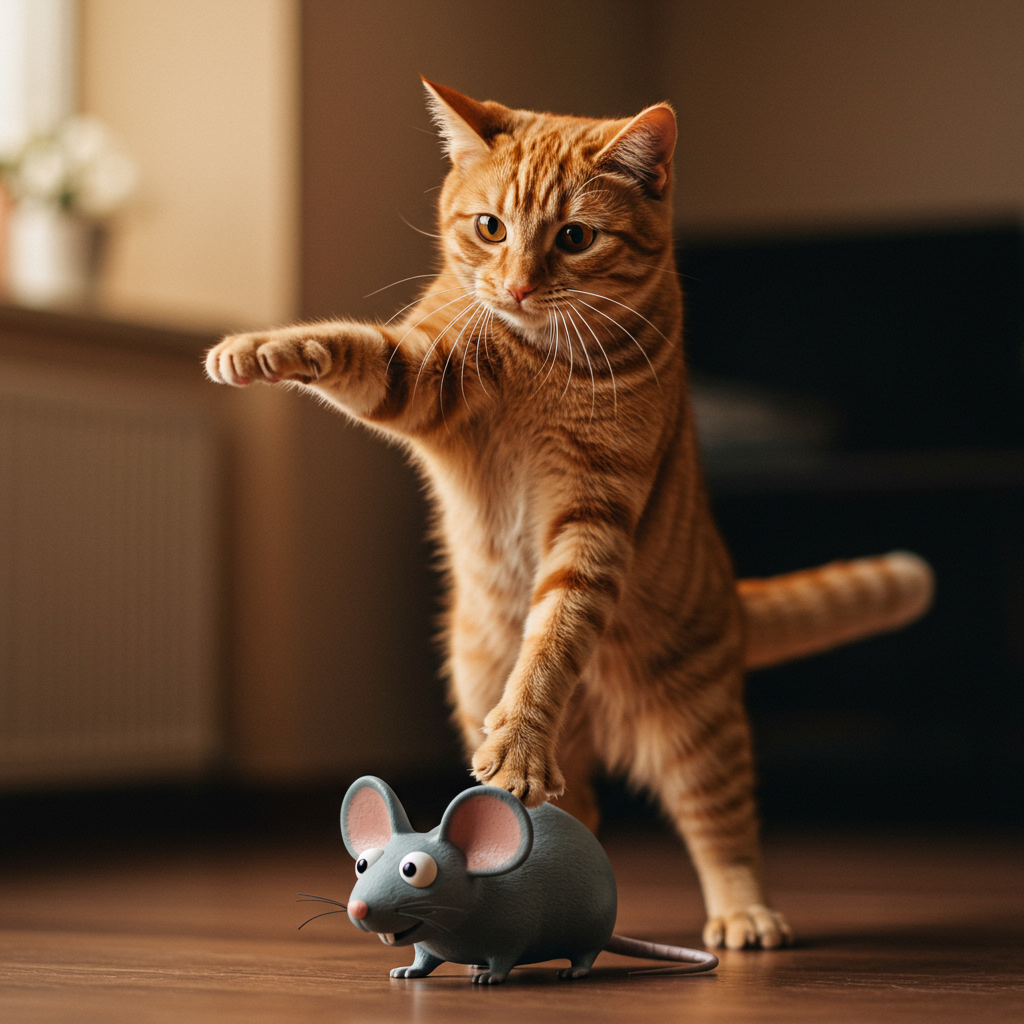

In [ ]:
# Save images to files
for i, generated_image in enumerate(response.generated_images):
    image = Image.open(BytesIO(generated_image.image.image_bytes))
    image_path = f'generated_image_{i}.png'
    image.save(image_path)
    print(f"Image saved as '{image_path}'")

    # Optional: also display the image
    display(image)

#### Gemini Image Generation Models

Available models for Gemini image generation:

- imagen-3.0-generate-002: Latest generation model with high-quality results
- imagen-3.0-generate-001: Standard generation model with good quality  
- imagen-3.0-fast-generate-001: Optimized for speed with reasonable quality
- imagegeneration@006: Legacy model (earlier version)
- imagegeneration@005: Legacy model (earlier version)
- imagegeneration@002: Legacy model (earliest version)

Documentation: https://cloud.google.com/vertex-ai/generative-ai/docs/model-reference/imagen-api#python_1


In [ ]:
# Initialize the client with your API key
client = genai.Client(api_key=GOOGLE_API_KEY)

# Generate an image using Gemini 2.0 Flash experimental model
response = client.models.generate_images(
    model='imagen-3.0-generate-002',
    prompt='Cat dancing on top of a mouse',
    config=types.GenerateImagesConfig(
        # Number of images to generate (1-4, default is 4)
        number_of_images=1,

        # Aspect ratio options: "1:1" (default), "3:4", "4:3", "9:16", "16:9"
        aspect_ratio="1:1",

        # Safety filter level options:
        # "BLOCK_LOW_AND_ABOVE" - Block when probability/severity is LOW, MEDIUM, or HIGH
        # "BLOCK_MEDIUM_AND_ABOVE" - Block when probability/severity is MEDIUM or HIGH
        # "BLOCK_ONLY_HIGH" - Block when probability/severity is HIGH
        safety_filter_level = "block_low_and_above",

        # Person generation options:
        # "DONT_ALLOW" - Block generation of images of people
        # "ALLOW_ADULT" - Generate images of adults, not children (default)
        person_generation="allow_adult"
    )
)

Image saved as 'generated_image_0.png'


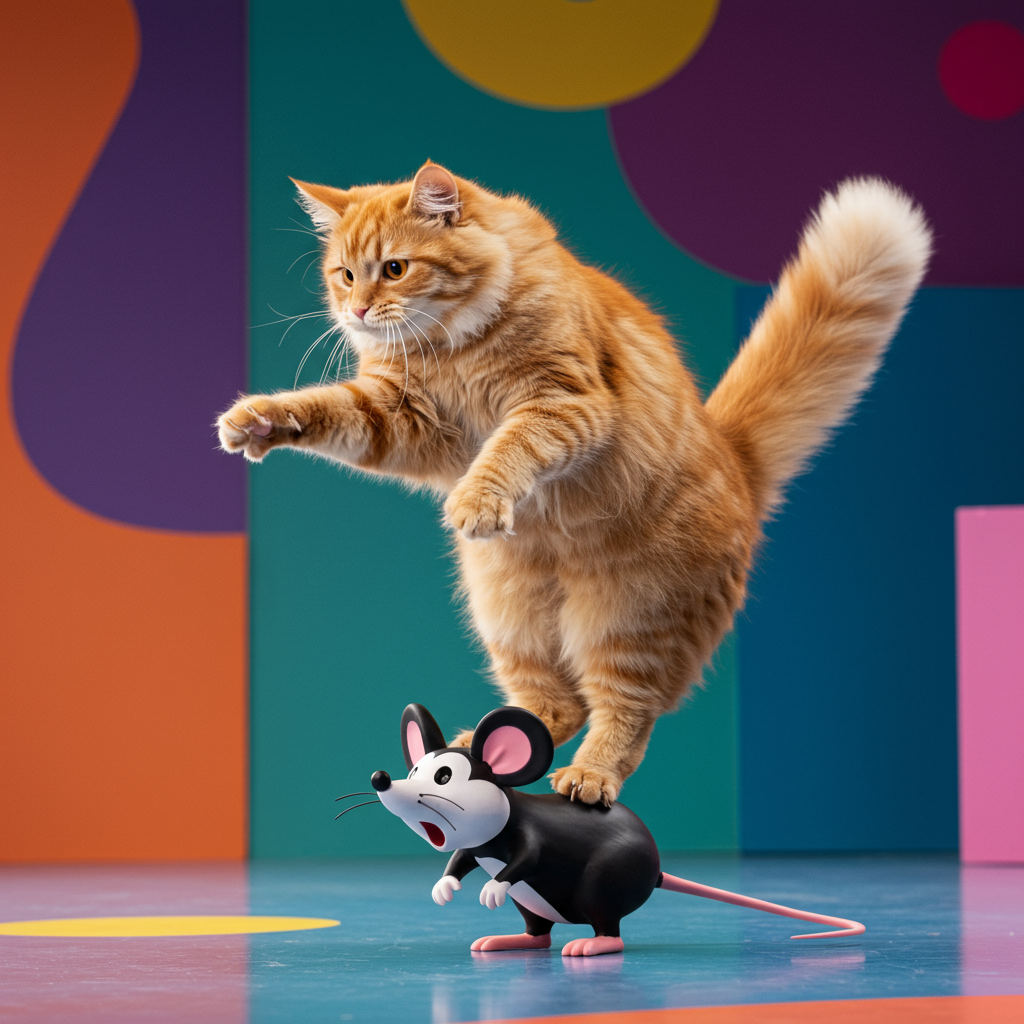

In [ ]:
# Save images to files
for i, generated_image in enumerate(response.generated_images):
    image = Image.open(BytesIO(generated_image.image.image_bytes))
    image_path = f'generated_image_{i}.png'
    image.save(image_path)
    print(f"Image saved as '{image_path}'")

    # Optional: also display the image
    display(image)

## Next Steps

### Useful API references:

Check out the [Google GenAI SDK](https://github.com/googleapis/python-genai) for more details on the new SDK.

### Related examples

For more detailed examples using Gemini 2.0, check the [Gemini 2.0 folder of the cookbook](https://github.com/google-gemini/cookbook/tree/main/gemini-2/). You'll learn how to use the [Live API](./Get_started_LiveAPI.ipynb), juggle with [multiple tools](../examples/LiveAPI_plotting_and_mapping.ipynb) or use Gemini 2.0 [spatial understanding](./Spatial_understanding.ipynb) abilities.

Also check the [experimental Gemini 2.0 Flash Thinking](./Get_started_thinking.ipynb) model that explicitly showcases its thoughts and can manage more complex reasonings.